# 02 — Descriptive Analysis

**Input**: `data/processed/anonymized.csv` (and auxiliary long-form files)

**Outputs**: PDF figures in `figures/` + tables in `data/processed/tables/`

**Goals**:
- Consolidated demographic Table 2 (replaces 3 figures)
- Diverging stacked bar for skills (Q8), importance (Q11), priority (Q13)
- Discussion and support frequency (Q19, Q22)
- Bar chart of Q9 words (raw frequency — lemmatization goes to notebook 04)
- Table with Wilson 95% CI for all main proportions
- Replace the 11 `example-image-duck` placeholders

In [9]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.insert(0, str(Path.cwd()))
import utils as U

U.setup_matplotlib()
TABLES = U.DATA_PROC / "tables"
TABLES.mkdir(exist_ok=True)

df = U.load_anonymized()
imp_long = pd.read_csv(U.DATA_PROC / "likert_importance.csv")
pri_long = pd.read_csv(U.DATA_PROC / "likert_priority.csv")
skills_long = pd.read_csv(U.DATA_PROC / "skills.csv")
words = pd.read_csv(U.DATA_PROC / "words.csv")
print(f"N={len(df)}, importance={len(imp_long)}, priority={len(pri_long)}")

N=41, importance=533, priority=533


## 1. Table 2 — Demographic characterization

Consolidates into **one table** what used to be 3 figures (gender/role/age) + seniority + education + projects + region. Output: LaTeX to `tables/`.

In [10]:
def freq_table(series: pd.Series, label: str, order=None) -> pd.DataFrame:
    counts = series.value_counts(dropna=False)
    if order is not None:
        counts = counts.reindex(order).fillna(0).astype(int)
    pct = (counts / counts.sum() * 100).round(1)
    out = pd.DataFrame({"Category": counts.index, "n": counts.values, "%": pct.values})
    out.insert(0, "Variable", "")
    out.iloc[0, 0] = label
    return out

blocks = [
    freq_table(df["gender"], "Gender"),
    freq_table(df["age"], "Age band",
               order=["18-24 anos", "25-34 anos", "35-44 anos", "45-54 anos", "55-64 anos"]),
    freq_table(df["region"], "Region",
               order=["North", "Northeast", "Central-West", "Southeast", "South"]),
    freq_table(df["education"], "Education"),
    freq_table(df["role_group"], "Role"),
    freq_table(df["seniority"], "Seniority",
               order=list(U.SENIORITY_ORDINAL.keys())),
]
demo_table = pd.concat(blocks, ignore_index=True)
demo_table = demo_table[demo_table["n"] > 0].reset_index(drop=True)
demo_table

,Variable,Category,n,%
0,Gender,Homem,24,58.5
1,,Mulher,8,19.5
2,,Men,7,17.1
3,,Woman,2,4.9
4,Age band,18-24 anos,5,15.6
5,,25-34 anos,17,53.1
6,,35-44 anos,7,21.9
7,,45-54 anos,3,9.4
8,Region,North,1,2.9
9,,Northeast,23,67.6


In [11]:
# # projects: descriptive stats
proj = df["n_projects"]
proj_stats = pd.Series({
    "min": int(proj.min()),
    "Q1": float(proj.quantile(0.25)),
    "median": float(proj.median()),
    "Q3": float(proj.quantile(0.75)),
    "max": int(proj.max()),
    "mean": float(proj.mean()),
})
print("ML projects already participated in:")
print(proj_stats.round(1).to_string())

ML projects already participated in:
min        0.0
Q1         2.0
median     4.0
Q3         7.0
max       40.0
mean       6.5


In [12]:
# Saves LaTeX table that will go in as Table 2 in the paper
def df_to_latex_demo(df: pd.DataFrame) -> str:
    lines = [
        "\\begin{table}[t]",
        "\\caption{Respondent characterization ($n=32$).}",
        "\\label{tab:demographics}",
        "\\centering",
        "\\small",
        "\\begin{tabular}{lp{4.5cm}rr}",
        "\\toprule",
        "\\textbf{Variable} & \\textbf{Category} & \\textbf{n} & \\textbf{\\%} \\\\",
        "\\midrule",
    ]
    for _, row in df.iterrows():
        var = row["Variable"] if row["Variable"] else ""
        cat = str(row["Category"]).replace("_", "\\_")
        lines.append(f"{var} & {cat} & {row['n']} & {row['%']:.1f} \\\\")
    lines.extend(["\\bottomrule", "\\end{tabular}", "\\end{table}"])
    return "\n".join(lines)

(TABLES / "demographics.tex").write_text(df_to_latex_demo(demo_table))
print("[saved] tables/demographics.tex")

[saved] tables/demographics.tex


## 2. Diverging stacked bar — generic function

Centers Likerts at Neutral=0. Negatives go to the left, positives to the right.

In [13]:
def diverging_stacked(
    long_df: pd.DataFrame,
    item_col: str,
    value_col: str,
    item_labels: dict[str, str],
    level_labels: list[str],
    title: str,
    figsize: tuple[float, float] = (7.0, 4.5),
    palette: list[str] | None = None,
    sort_by_positive: bool = True,
    ci_df: pd.DataFrame | None = None,
) -> plt.Figure:
    """Diverging stacked bar for Likerts with optional Wilson 95% CI error bars.

    Parameters
    ----------
    long_df : long format with columns [item_col, value_col]; value_col is int 1..N
    item_labels : dict of key (in item_col) -> nice label for the y-axis
    level_labels : list of N labels (1st = most negative). If 5 levels, 3rd is neutral.
    ci_df : optional DataFrame indexed by item keys with columns
            'pct_top2', 'ci_lo', 'ci_hi' (all in percent, 0-100).
            When provided, draws a horizontal error bar on the positive side of each bar.
    """
    n_levels = len(level_labels)
    if palette is None:
        palette = U.PALETTE_LIKERT_5 if n_levels == 5 else None
    items = list(item_labels.keys())
    counts = (long_df.groupby(item_col)[value_col]
              .value_counts().unstack(fill_value=0)
              .reindex(index=items, columns=range(1, n_levels + 1), fill_value=0))
    pct = counts.div(counts.sum(axis=1), axis=0) * 100
    if sort_by_positive:
        positive = pct[[n_levels - 1, n_levels]] if n_levels >= 4 else pct[[n_levels]]
        order = positive.sum(axis=1).sort_values().index
        pct = pct.loc[order]
        items = list(order)
    # Center: for 5 levels, neutral is 3 (central index). Negatives {1,2}, Positives {4,5}.
    if n_levels == 5:
        neg_levels, neutral, pos_levels = [1, 2], 3, [4, 5]
    elif n_levels == 4:
        neg_levels, neutral, pos_levels = [1, 2], None, [3, 4]
    else:
        raise ValueError("diverging_stacked expects 4 or 5 levels")

    fig, ax = plt.subplots(figsize=figsize)
    y = np.arange(len(items))
    # Negatives: stack with sign flipped, from outermost (1) to most central (2)
    left_offset = -pct[neg_levels[1]].values - pct[neg_levels[0]].values
    cur = left_offset.copy()
    for lvl, color in zip(neg_levels, palette[:len(neg_levels)]):
        widths = pct[lvl].values
        ax.barh(y, widths, left=cur, color=color,
                edgecolor="white", linewidth=0.5, label=level_labels[lvl - 1])
        cur += widths
    if neutral is not None:
        widths = pct[neutral].values
        # Center neutral around 0
        ax.barh(y, widths, left=-widths / 2, color=palette[neutral - 1],
                edgecolor="white", linewidth=0.5, label=level_labels[neutral - 1])
    cur = (pct[neutral].values / 2) if neutral is not None else np.zeros(len(items))
    for lvl, color in zip(pos_levels, palette[-len(pos_levels):]):
        widths = pct[lvl].values
        ax.barh(y, widths, left=cur, color=color,
                edgecolor="white", linewidth=0.5, label=level_labels[lvl - 1])
        cur += widths

    # ── Wilson 95% CI error bars ──────────────────────────────────────────
    if ci_df is not None:
        ci_aligned = ci_df.reindex(items)

        # Offset do lado positivo: metade do neutro (igual ao `cur` antes do loop positivo)
        neutral_offset = (pct[neutral].values / 2) if neutral is not None else np.zeros(len(items))

        # Centro da barra de erro = onde pct_top2 cai no eixo divergente
        x_center = neutral_offset + ci_aligned["pct_top2"].values
        x_lo_err = np.clip(x_center - (neutral_offset + ci_aligned["ci_lo"].values), 0, None)
        x_hi_err = np.clip((neutral_offset + ci_aligned["ci_hi"].values) - x_center, 0, None)

        ax.errorbar(
            x_center, y,
            xerr=[x_lo_err, x_hi_err],
            fmt="none",
            ecolor="black",
            elinewidth=1.0,
            capsize=3,
            capthick=1.0,
            zorder=5,
            label="95% CI (Wilson)",
        )

    ax.axvline(0, color="black", linewidth=0.6)
    ax.set_yticks(y)
    ax.set_yticklabels([item_labels[i] for i in items])
    ax.set_xlabel("% of responses")
    ax.set_xlim(-100, 100)
    ax.set_xticks([-100, -75, -50, -25, 0, 25, 50, 75, 100])
    ax.set_xticklabels(["100%", "75%", "50%", "25%", "0", "25%", "50%", "75%", "100%"])
    ax.set_title(title)
    ax.grid(axis="y", visible=False)
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12),
              ncol=n_levels + (1 if ci_df is not None else 0), frameon=False)
    return fig

In [14]:
def _wilson_ci_df(long_df, item_col, value_col, items, top_levels) -> pd.DataFrame:
    """Compute % top-2 and Wilson 95% CI for each item in *items*.

    Parameters
    ----------
    long_df : long-format DataFrame with columns [item_col, value_col]
    items   : list of keys (values in item_col)
    top_levels : iterable of Likert values that count as "positive" (e.g. [4, 5])

    Returns
    -------
    DataFrame indexed by item key with columns pct_top2, ci_lo, ci_hi (all in %).
    """
    rows = {}
    for key in items:
        s = long_df.loc[long_df[item_col] == key, value_col].dropna()
        n = len(s)
        if n == 0:
            rows[key] = {"pct_top2": float("nan"), "ci_lo": float("nan"), "ci_hi": float("nan")}
            continue
        successes = int(s.isin(top_levels).sum())
        lo, hi = U.wilson_ci(successes, n)
        rows[key] = {"pct_top2": successes / n * 100,
                     "ci_lo": lo * 100,
                     "ci_hi": hi * 100}
    return pd.DataFrame(rows).T

## 3. Skills (Q8) — replaces 5 figures with 1

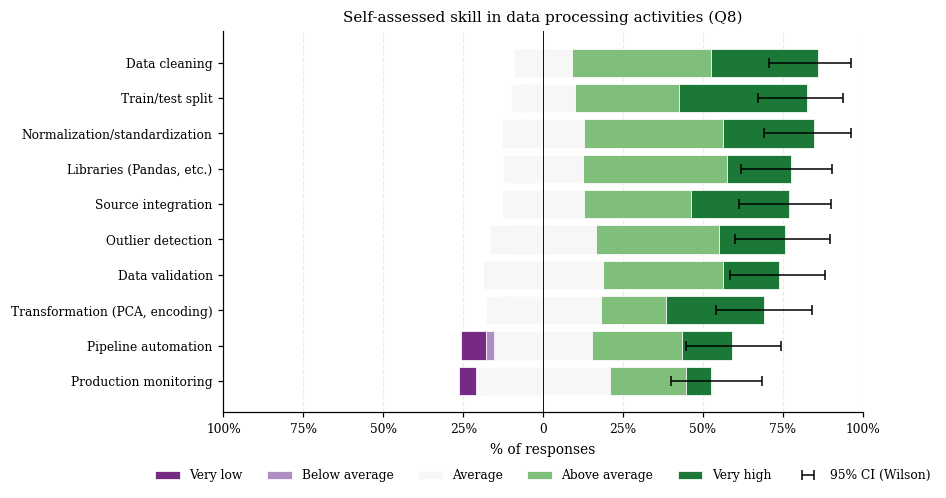

In [15]:
skills_renamed = skills_long.copy()
_skill_items = list(U.SKILL_LABELS_PT.keys())
_skill_ci = _wilson_ci_df(
    skills_renamed.dropna(), "activity", "skill", _skill_items, top_levels=[4, 5]
)
fig = diverging_stacked(
    skills_renamed.dropna(),
    item_col="activity",
    value_col="skill",
    item_labels=U.SKILL_LABELS_PT,
    level_labels=["Very low", "Below average", "Average", "Above average", "Very high"],
    title="Self-assessed skill in data processing activities (Q8)",
    figsize=(7.5, 4.5),
    ci_df=_skill_ci,
)
U.save_fig(fig, "skills_diverging")
plt.show()

## 9. Table with Wilson 95% CI for main proportions

In [16]:
rows = []
for char_key, char_label in U.CHARACTERISTICS_PT.items():
    imp_col = f"imp_{char_key}"
    pri_col = f"pri_{char_key}"
    n_imp = df[imp_col].notna().sum()
    n_pri = df[pri_col].notna().sum()
    suc_imp = (df[imp_col] >= 4).sum()
    suc_pri = (df[pri_col] >= 4).sum()
    lo_i, hi_i = U.wilson_ci(int(suc_imp), int(n_imp))
    lo_p, hi_p = U.wilson_ci(int(suc_pri), int(n_pri))
    rows.append({
        "Characteristic": char_label,
        "% Important/Very": f"{suc_imp/n_imp*100:.0f}%",
        "CI95 (imp.)": f"[{lo_i*100:.0f}–{hi_i*100:.0f}]",
        "% High/Essential": f"{suc_pri/n_pri*100:.0f}%",
        "CI95 (pri.)": f"[{lo_p*100:.0f}–{hi_p*100:.0f}]",
        "n": int(n_imp),
    })
ci_table = pd.DataFrame(rows)
# Sort by % importance
ci_table["_sort"] = ci_table["% Important/Very"].str.rstrip("%").astype(float)
ci_table = ci_table.sort_values("_sort", ascending=False).drop(columns="_sort").reset_index(drop=True)
ci_table

,Characteristic,% Important/Very,CI95 (imp.),% High/Essential,CI95 (pri.),n
0,Precision,95%,[84–99],93%,[81–97],41
1,Completeness,95%,[84–99],85%,[72–93],41
2,Consistency,95%,[84–99],90%,[77–96],41
3,Credibility,95%,[84–99],85%,[72–93],41
4,Reliability,93%,[81–97],85%,[72–93],41
5,Availability,83%,[69–91],71%,[56–82],41
6,Efficiency,80%,[66–90],63%,[48–76],41
7,Currentness,76%,[61–86],51%,[36–66],41
8,Traceability,76%,[61–86],56%,[41–70],41
9,Compliance,68%,[53–80],61%,[46–74],41


## 11. Aggregated skills — % "Above average/Very high"

In [17]:
# LaTeX table with proportions + CI
def df_to_latex_ci(df: pd.DataFrame) -> str:
    lines = [
        "\\begin{table}[t]",
        "\\caption{Proportions of \\textit{Important/Very important} (Q11) and \\textit{High priority/Essential} (Q13) responses with Wilson 95\\% CI ($n=32$).}",
        "\\label{tab:characteristics-ci}",
        "\\centering",
        "\\small",
        "\\begin{tabular}{lcccc}",
        "\\toprule",
        "\\textbf{Characteristic} & \\textbf{\\% Imp.} & \\textbf{95\\% CI} & \\textbf{\\% Pri.} & \\textbf{95\\% CI} \\\\",
        "\\midrule",
    ]
    for _, r in df.iterrows():
        lines.append(f"{r['Characteristic']} & {r['% Important/Very']} & {r['CI95 (imp.)']} & {r['% High/Essential']} & {r['CI95 (pri.)']} \\\\")
    lines.extend(["\\bottomrule", "\\end{tabular}", "\\end{table}"])
    return "\n".join(lines)

(TABLES / "characteristics_ci.tex").write_text(df_to_latex_ci(ci_table))
print("[saved] tables/characteristics_ci.tex")

skill_pct = []
for col in U.SKILL_COLS:
    s = df[col].dropna()
    if len(s) == 0:
        continue
    high = (s >= 4).sum()
    lo, hi = U.wilson_ci(int(high), int(len(s)))
    skill_pct.append({
        "Activity": U.SKILL_LABELS_PT[col],
        "% High": high / len(s) * 100,
        "CI95": f"[{lo*100:.0f}–{hi*100:.0f}]",
        "n": int(len(s)),
    })
skill_pct_df = pd.DataFrame(skill_pct).sort_values("% High", ascending=False).reset_index(drop=True)
skill_pct_df.round(1)

[saved] tables/characteristics_ci.tex


,Activity,% High,CI95,n
0,Data cleaning,76.9,[62–87],39
1,Train/test split,72.5,[57–84],40
2,Normalization/standardization,71.8,[56–83],39
3,"Libraries (Pandas, etc.)",65.0,[50–78],40
4,Source integration,64.1,[48–77],39
5,Outlier detection,59.0,[43–73],39
6,Data validation,55.0,[40–69],40
7,"Transformation (PCA, encoding)",51.3,[36–66],39
8,Pipeline automation,43.6,[29–59],39
9,Production monitoring,31.6,[19–47],38


## 4. Importance (Q11) — 13 characteristics

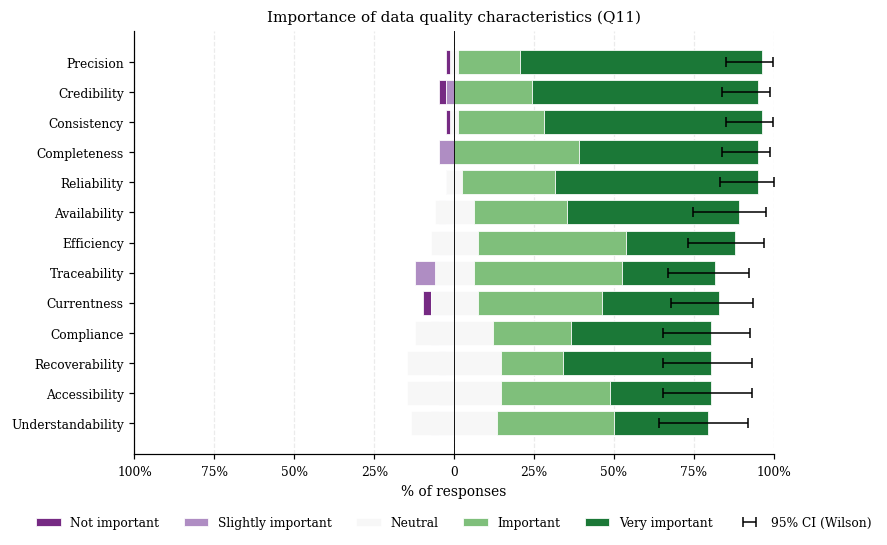

In [18]:
imp_renamed = imp_long.copy()
_imp_items = list(U.CHARACTERISTICS_PT.keys())
_imp_ci = _wilson_ci_df(
    imp_renamed, "characteristic", "importance", _imp_items, top_levels=[4, 5]
)
fig = diverging_stacked(
    imp_renamed,
    item_col="characteristic",
    value_col="importance",
    item_labels=U.CHARACTERISTICS_PT,
    level_labels=["Not important", "Slightly important", "Neutral", "Important", "Very important"],
    title="Importance of data quality characteristics (Q11)",
    figsize=(7.5, 5.0),
    ci_df=_imp_ci,
)
U.save_fig(fig, "importance_diverging")
plt.show()

## 5. Priority (Q13) — 13 characteristics

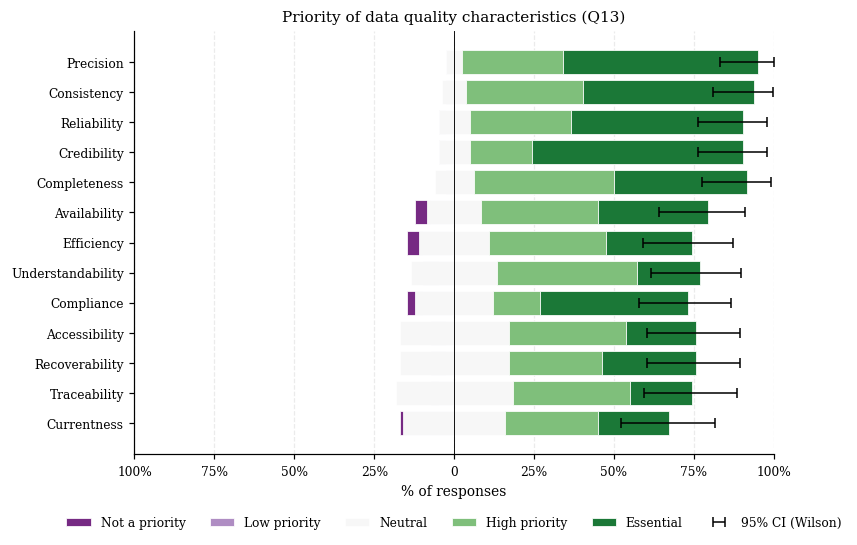

In [19]:
_pri_items = list(U.CHARACTERISTICS_PT.keys())
_pri_ci = _wilson_ci_df(
    pri_long, "characteristic", "priority", _pri_items, top_levels=[4, 5]
)
fig = diverging_stacked(
    pri_long,
    item_col="characteristic",
    value_col="priority",
    item_labels=U.CHARACTERISTICS_PT,
    level_labels=["Not a priority", "Low priority", "Neutral", "High priority", "Essential"],
    title="Priority of data quality characteristics (Q13)",
    figsize=(7.5, 5.0),
    ci_df=_pri_ci,
)
U.save_fig(fig, "priority_diverging")
plt.show()

## 7. Frequencies (Q19 discussion + Q22 support)

Two distributions in 1 figure sharing aesthetics.

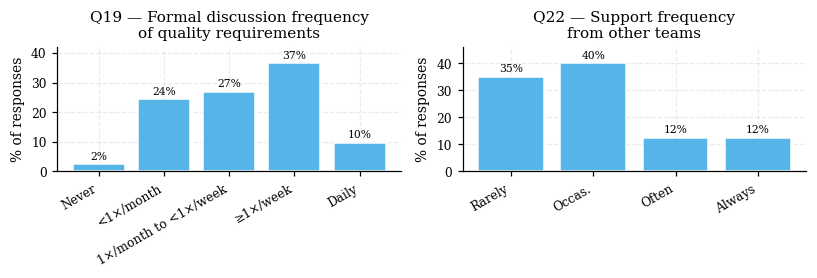

In [20]:
disc_labels = ["Never", "<1×/month", "1×/month to <1×/week", "≥1×/week", "Daily"]
supp_labels = ["Rarely", "Occas.", "Often", "Always"]

fig, axes = plt.subplots(1, 2, figsize=(7.5, 2.6))

for ax, col, labels, title in [
    (axes[0], "discussion_freq", disc_labels,
     "Q19 — Formal discussion frequency\nof quality requirements"),
    (axes[1], "support_freq", supp_labels,
     "Q22 — Support frequency\nfrom other teams"),
]:
    counts = df[col].value_counts(dropna=False).reindex(range(1, len(labels) + 1), fill_value=0)
    pct = counts / counts.sum() * 100
    ax.bar(range(len(labels)), pct.values, color=U.PALETTE_WONG[2], edgecolor="white")
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=30, ha="right")
    ax.set_ylabel("% of responses")
    ax.set_title(title)
    ax.set_ylim(0, max(pct.values) * 1.15)
    for i, v in enumerate(pct.values):
        ax.text(i, v + 1, f"{v:.0f}%", ha="center", va="bottom", fontsize=7)

fig.tight_layout()
U.save_fig(fig, "frequencies")
plt.show()

## 10. Heatmap subgroups × characteristics (% top-2)

Rows = subgroup, columns = characteristic, value = % "Important/Very important". Quickly highlights visual differences (Diversity Matters style).

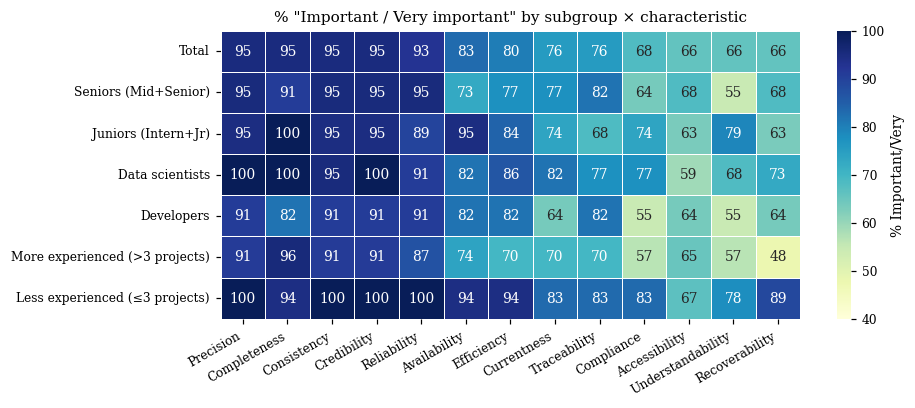

In [21]:
def pct_top2(df_sub: pd.DataFrame, col: str) -> float:
    s = df_sub[col].dropna()
    if len(s) == 0:
        return float("nan")
    return (s >= 4).sum() / len(s) * 100

groups = {
    "Total": df,
    "Seniors (Mid+Senior)": df[df["seniority_group"] == "senior"],
    "Juniors (Intern+Jr)": df[df["seniority_group"] == "junior"],
    "Data scientists": df[df["role_group"] == "data_scientist"],
    "Developers": df[df["role_group"] == "developer"],
    "More experienced (>3 projects)": df[df["n_projects"] > 3],
    "Less experienced (≤3 projects)": df[df["n_projects"] <= 3],
}

heat = pd.DataFrame(
    {label: [pct_top2(g, f"imp_{c}") for c in U.CHARACTERISTICS_PT.keys()] for label, g in groups.items()},
    index=[U.CHARACTERISTICS_PT[c] for c in U.CHARACTERISTICS_PT.keys()],
).T
# Sort columns by total %
heat = heat[heat.loc["Total"].sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(8.5, 3.4))
sns.heatmap(heat, annot=True, fmt=".0f", cmap="YlGnBu", cbar_kws={"label": "% Important/Very"},
            linewidths=0.4, linecolor="white", ax=ax, vmin=40, vmax=100)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("% \"Important / Very important\" by subgroup × characteristic")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
U.save_fig(fig, "heatmap_importance_subgroups")
plt.show()

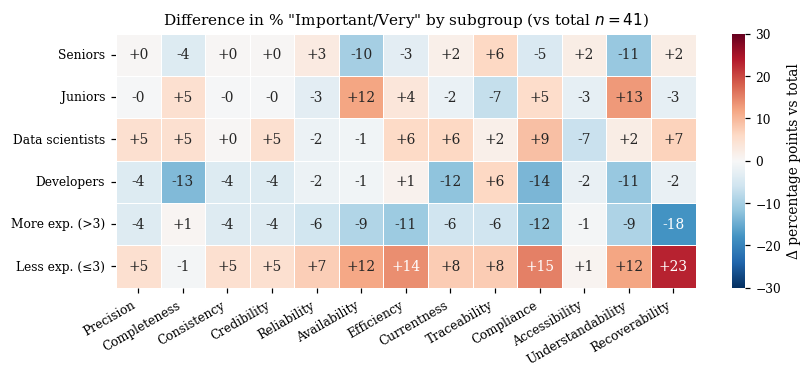

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
U.setup_matplotlib()

def pct_top2(g, col):
    s = g[col].dropna()
    return (s >= 4).sum() / len(s) * 100 if len(s) else np.nan

groups_def = {
    "Seniors": df[df["seniority_group"] == "senior"],
    "Juniors": df[df["seniority_group"] == "junior"],
    "Data scientists": df[df["role_group"] == "data_scientist"],
    "Developers": df[df["role_group"] == "developer"],
    "More exp. (>3)": df[df["n_projects"] > 3],
    "Less exp. (≤3)": df[df["n_projects"] <= 3],
}
total_imp = pd.Series({c: pct_top2(df, f"imp_{c}") for c in U.CHARACTERISTICS_PT.keys()})
diffs = pd.DataFrame({
    label: [pct_top2(g, f"imp_{c}") - total_imp[c] for c in U.CHARACTERISTICS_PT.keys()]
    for label, g in groups_def.items()
}, index=[U.CHARACTERISTICS_PT[c] for c in U.CHARACTERISTICS_PT.keys()]).T
diffs = diffs[total_imp.sort_values(ascending=False).rename(lambda c: U.CHARACTERISTICS_PT[c]).index]

fig, ax = plt.subplots(figsize=(8.5, 3.0))
sns.heatmap(diffs, annot=True, fmt="+.0f", cmap="RdBu_r", center=0,
            cbar_kws={"label": "Δ percentage points vs total"},
            linewidths=0.4, linecolor="white", ax=ax, vmin=-30, vmax=30)
ax.set_title("Difference in % \"Important/Very\" by subgroup (vs total $n=41$)")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
U.save_fig(fig, "heatmap_subgroup_diff")
plt.show()

## 12. Final descriptive summary

In [22]:
# Key findings the paper needs to cite
summary = {
    "n": len(df),
    "n_pt": int((df["language"] == "pt").sum()),
    "n_en": int((df["language"] == "en").sum()),
    "%_men": (df["gender_norm"] == "male").mean() * 100,
    "%_NE": (df["region"] == "Northeast").mean() * 100,
    "%_international": (df["region"] == "International").mean() * 100,
    "%_DS": (df["role_group"] == "data_scientist").mean() * 100,
    "%_seniors": (df["seniority_group"] == "senior").mean() * 100,
    "projects_median": int(df["n_projects"].median()),
    "%_disc_<1month": ((df["discussion_freq"] <= 2).sum() / df["discussion_freq"].notna().sum() * 100),
    "%_supp_<=occasional": ((df["support_freq"] <= 2).sum() / df["support_freq"].notna().sum() * 100),
    "most_imp_charac": ci_table.iloc[0]["Characteristic"],
    "least_imp_charac": ci_table.iloc[-1]["Characteristic"],
}
for k, v in summary.items():
    if isinstance(v, float):
        print(f"{k}: {v:.1f}")
    else:
        print(f"{k}: {v}")

import json
(TABLES / "descriptive_summary.json").write_text(json.dumps({k: (float(v) if isinstance(v, (int, float)) else v) for k, v in summary.items()}, ensure_ascii=False, indent=2))
print("\n[saved] tables/descriptive_summary.json")

n: 41
n_pt: 32
n_en: 9
%_men: 75.6
%_NE: 56.1
%_international: 14.6
%_DS: 53.7
%_seniors: 53.7
projects_median: 4
%_disc_<1month: 26.8
%_supp_<=occasional: 75.0
most_imp_charac: Precision
least_imp_charac: Recoverability

[saved] tables/descriptive_summary.json


## 13. Internal reliability — Cronbach α and McDonald ω

Before treating Q11/Q13 as aggregated "constructs" (e.g., "% High Importance"),
we measure internal consistency of the blocks as Likert scales.

- **Cronbach α**: assumes tau-equivalence; pingouin returns a bootstrap 95% CI.
- **McDonald ω total**: 1-factor analysis on standardized items (`U.mcdonald_omega`); less sensitive to tau-equivalence violations.

Convention: α ≥ 0.7 acceptable, ≥ 0.8 good, ≥ 0.9 excellent (Nunnally 1978).


In [23]:
import pingouin as pg

def reliability_block(name: str, items: pd.DataFrame) -> dict:
    items = items.dropna()
    alpha, ci = pg.cronbach_alpha(data=items)
    omega = U.mcdonald_omega(items)
    return {"block": name, "n_subj": len(items), "k_items": items.shape[1],
            "cronbach_alpha": float(alpha),
            "alpha_ci_lo": float(ci[0]), "alpha_ci_hi": float(ci[1]),
            "mcdonald_omega": omega}

reli_imp = reliability_block("Q11 importance", df[U.IMP_COLS])
reli_pri = reliability_block("Q13 priority", df[U.PRI_COLS])
reli_skill = reliability_block("Q8 skills", df[U.SKILL_COLS])

reliability = pd.DataFrame([reli_imp, reli_pri, reli_skill])
print(reliability.to_string(index=False))
print()
for r in [reli_imp, reli_pri, reli_skill]:
    interp = (
        "excellent" if r["cronbach_alpha"] >= 0.9 else
        "good" if r["cronbach_alpha"] >= 0.8 else
        "acceptable" if r["cronbach_alpha"] >= 0.7 else
        "questionable" if r["cronbach_alpha"] >= 0.6 else
        "inadequate"
    )
    print(f"{r['block']}: α={r['cronbach_alpha']:.3f} "
          f"[{r['alpha_ci_lo']:.3f}, {r['alpha_ci_hi']:.3f}], "
          f"ω={r['mcdonald_omega']:.3f} — {interp} reliability.")


         block  n_subj  k_items  cronbach_alpha  alpha_ci_lo  alpha_ci_hi  mcdonald_omega
Q11 importance      41       13        0.932179        0.897        0.959        0.933957
  Q13 priority      41       13        0.920765        0.880        0.952        0.922780
     Q8 skills      36       10        0.910870        0.860        0.949        0.914637

Q11 importance: α=0.932 [0.897, 0.959], ω=0.934 — excellent reliability.
Q13 priority: α=0.921 [0.880, 0.952], ω=0.923 — excellent reliability.
Q8 skills: α=0.911 [0.860, 0.949], ω=0.915 — excellent reliability.


In [24]:
reliability.to_csv(TABLES / "reliability.csv", index=False)
print(f"-> tables/reliability.csv")


-> tables/reliability.csv
